# Siamese CNN Training for Fragmented ID Resolution

This notebook trains an end-to-end Siamese network that:
1. Takes raw text pairs as input
2. Embeds both with a shared CharCNN encoder
3. Classifies whether they're duplicates

In [61]:
# Imports and Setup
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import custom modules
sys.path.append('src')
from model import CharCNNEncoder
from model_utils import char_to_idx, vocab_size
from pair_text_dataset import PairTextDataset
from siamese_cnn import SiameseCNN
from siamese_train_utils import train_epoch, evaluate, print_evaluation_report

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Vocab size: {vocab_size}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
Vocab size: 38


In [62]:

# ============================================================================
# UTILITY FUNCTIONS FOR DATA LOADING, TRAINING, AND EVALUATION
# ============================================================================

def load_and_create_datasets(train_path, val_path, test_path, features, max_len=100, batch_size=128):
    """Load CSV files and create datasets with DataLoaders"""
    print("\n" + "="*60)
    print(f"LOADING DATA: {train_path}, {val_path}, {test_path}")
    print("="*60)
    
    # Load data
    train_data = pd.read_csv(train_path)
    val_data = pd.read_csv(val_path)
    test_data = pd.read_csv(test_path)
    
    # Create datasets
    train_dataset = PairTextDataset(data=train_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    val_dataset = PairTextDataset(data=val_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    test_dataset = PairTextDataset(data=test_data, char_to_idx=char_to_idx, max_len=max_len, features=features)
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nDataLoaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    
    return train_loader, val_loader, test_loader


def train_and_evaluate_model(train_loader, val_loader, model_name, epochs=30, learning_rate=0.001):
    """Initialize, train, and evaluate a Siamese CNN model"""
    print("\n" + "="*60)
    print(f"TRAINING MODEL: {model_name}")
    print("="*60)
    
    # Hyperparameters
    EMBED_DIM = 32
    NUM_FILTERS = 128
    KERNEL_SIZES = (3, 4, 5)
    DROPOUT = 0.3
    CNN_OUTPUT_DIM = 128
    
    # Initialize model
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=EMBED_DIM,
        num_filters=NUM_FILTERS,
        kernel_sizes=KERNEL_SIZES,
        dropout=DROPOUT,
        cnn_output_dim=CNN_OUTPUT_DIM
    ).to(device)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    
    # Training history
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    best_epoch = 0
    
    os.makedirs('models', exist_ok=True)
    
    # Training loop
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        
        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning Rate: {current_lr:.6f}")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            model_path = f'models/best_{model_name}.pth'
            torch.save(model.state_dict(), model_path)
            print(f"🎯 NEW BEST F1: {best_val_f1:.4f}")
    
    print(f"\nBest Validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
    
    return model, history, best_val_f1, best_epoch


def plot_and_save_history(history, model_name, title):
    """Plot and save training history"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {title}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy - {title}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    best_f1 = max(history['val_f1'])
    axes[2].plot(history['train_f1'], label='Train F1', marker='o', linewidth=2)
    axes[2].plot(history['val_f1'], label='Val F1', marker='s', linewidth=2)
    axes[2].axhline(y=best_f1, color='r', linestyle='--', linewidth=2, label=f'Best F1: {best_f1:.4f}')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title(f'F1 Score - {title}', fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_path = f'training_history_{model_name}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Training history plot saved as '{plot_path}'")
    
    # Save history as CSV
    history_df = pd.DataFrame(history)
    csv_path = f'training_history_{model_name}.csv'
    history_df.to_csv(csv_path, index=False)
    print(f"Training history CSV saved as '{csv_path}'")


def evaluate_on_test(model, test_loader, model_name, criterion, device):
    """Evaluate model on test set and save results"""
    print("\n" + "="*60)
    print(f"EVALUATING {model_name.upper()} ON TEST SET")
    print("="*60)
    
    model.eval()
    test_loss, test_acc, test_f1, test_labels, test_preds, test_probs = evaluate(
        model, test_loader, criterion, device
    )
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        test_labels, test_preds, test_probs
    )
    
    # Save results
    tn, fp, fn, tp = cm.ravel()
    with open(f'test_results_{model_name}.txt', 'w') as f:
        f.write("="*60 + "\n")
        f.write(f"TEST RESULTS - {model_name.upper()}\n")
        f.write("="*60 + "\n\n")
        f.write("Test Metrics:\n")
        f.write(f"  Loss: {test_loss:.4f}\n")
        f.write(f"  Accuracy: {test_acc:.4f}\n")
        f.write(f"  F1 Score: {final_f1:.4f}\n")
        f.write(f"  Precision: {precision:.4f}\n")
        f.write(f"  Recall: {recall:.4f}\n")
        f.write(f"  Specificity: {specificity:.4f}\n\n")
        f.write("Confusion Matrix:\n")
        f.write(f"  TN={tn:6d}  FP={fp:6d}\n")
        f.write(f"  FN={fn:6d}  TP={tp:6d}\n")
    
    print(f"Test results saved to 'test_results_{model_name}.txt'")
    
    return test_loss, test_acc, final_f1, precision, recall, specificity


def load_model_and_validate(model_name, val_loader, criterion, device):
    """Load model and evaluate on validation set"""
    print("\n" + "="*60)
    print(f"VALIDATING {model_name.upper()}")
    print("="*60)
    
    model = SiameseCNN(
        vocab_size=vocab_size,
        embed_dim=32,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        dropout=0.3,
        cnn_output_dim=128
    ).to(device)
    
    model_path = f'models/best_{model_name}.pth'
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    val_loss, val_acc, val_f1, val_labels, val_preds, val_probs = evaluate(
        model, val_loader, criterion, device
    )
    
    cm, precision, recall, specificity, final_f1 = print_evaluation_report(
        val_labels, val_preds, val_probs
    )
    
    print(f"\nValidation Results:")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  F1 Score: {final_f1:.4f}")
    
    return model, cm, precision, recall, specificity, final_f1


In [63]:
train_aug_data = pd.read_csv('data/train_pairs_aug.csv')
val_aug_data = pd.read_csv('data/val_pairs_aug.csv')
test_aug_data = pd.read_csv('data/test_pairs_aug.csv')
val_noaug_data = pd.read_csv('data/val_pairs.csv')
test_noaug_data = pd.read_csv('data/test_pairs.csv')

C:\Users\arpit\AppData\Local\Temp\ipykernel_17836\1818582478.py:1: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_aug_data = pd.read_csv('data/train_pairs_aug.csv')


Use PairTextDataset to seperate ID1 and ID2 info, tokenize and load data in batches

In [64]:
# Define features and hyperparameters
FEATURES = ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']
MAX_LEN = 100
BATCH_SIZE = 128
EPOCHS = 30

# Load augmented data and create DataLoaders
train_loader, val_loader, test_loader = load_and_create_datasets(
    'data/train_pairs_aug.csv',
    'data/val_pairs_aug.csv',
    'data/test_pairs_aug.csv',
    features=FEATURES,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE
)


LOADING DATA: data/train_pairs_aug.csv, data/val_pairs_aug.csv, data/test_pairs_aug.csv


C:\Users\arpit\AppData\Local\Temp\ipykernel_17836\1461057602.py:12: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(train_path)



Loaded 65503 pairs from the data
  - Duplicates: 13652
  - Non-duplicates: 51851
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 6901 pairs from the data
  - Duplicates: 2938
  - Non-duplicates: 3963
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

Loaded 7475 pairs from the data
  - Duplicates: 3048
  - Non-duplicates: 4427
  - Using features: ['first_name', 'midl_name', 'last_name', 'age', 'sex', 'street_name', 'zip_code', 'house_num', 'area_cd']

DataLoaders created:
  Train batches: 512
  Val batches: 54
  Test batches: 59


## Training with Hard Negative Weighting

Apply higher loss weight to confusing non-duplicate pairs (same name + different age, same address + different person, etc.) to force the model to learn better discrimination.


In [65]:
# Step 1: Compute hard negative weights
from hard_negative_weights import compute_hard_negative_weights

# Compute weights with configurable hyperparameters
hard_negative_weights_aug, is_hard_negative_aug = compute_hard_negative_weights(
    data=train_aug_data,
    hard_negative_weight=2.0,      # HYPERPARAMETER: 1.5, 2.0, 2.5, 3.0
    similarity_threshold=0.7,      # HYPERPARAMETER: 0.6, 0.7, 0.8
    return_mask=True
)

print(f"\nHard Negative Weights computed:")
print(f"  Shape: {hard_negative_weights_aug.shape}")
print(f"  Dtype: {hard_negative_weights_aug.dtype}")
print(f"  Unique values: {np.unique(hard_negative_weights_aug)}")



COMPUTING HARD NEGATIVE WEIGHTS
Hard negative weight: 2.0x
Similarity threshold: 0.7
  Computing name similarities (n=51851 non-duplicates)...

  Hard Negative Buckets:
    same_first_last_diff_age: 1
    same_first_and_age_diff_last: 17

SUMMARY
Total samples: 65,503
  Duplicates (label=1): 13,652 (20.8%)
  Non-duplicates (label=0): 51,851 (79.2%)
  Hard negatives: 18 (0.0%)

Weight distribution:
  Regular samples: 65,485 with weight 1.0x
  Hard negatives: 18 with weight 2.0x


Hard Negative Weights computed:
  Shape: (65503,)
  Dtype: float32
  Unique values: [1. 2.]


In [ ]:
# Step 2: Train model with hard negative weights using the wrapper function
from src.siamese_train_utils import train_with_hard_negatives

print("\n" + "="*70)
print("TRAINING WITH HARD NEGATIVE WEIGHTS (Augmented Data)")
print("="*70)

# Create optimizers for hard negative training
optimizer_hn = optim.Adam(model.parameters(), lr=0.001)
scheduler_hn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hn, 'max', patience=3, factor=0.5)

# Initialize fresh model for hard negative training
model_hn = SiameseCNN(
    vocab_size=vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    cnn_output_dim=128
).to(device)

optimizer_hn = optim.Adam(model_hn.parameters(), lr=0.001)
scheduler_hn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_hn, 'max', patience=3, factor=0.5)

# Train with hard negative weighting
model_hn, history_hn, best_val_f1_hn, best_epoch_hn = train_with_hard_negatives(
    model=model_hn,
    train_loader=train_loader,
    val_loader=val_loader,
    train_df=train_aug_data,
    criterion=criterion,
    optimizer=optimizer_hn,
    scheduler=scheduler_hn,
    device=device,
    epochs=EPOCHS,
    hard_negative_weight=2.0,      # HYPERPARAMETER to tune
    similarity_threshold=0.7       # HYPERPARAMETER to tune
)



TRAINING WITH HARD NEGATIVE WEIGHTS (Augmented Data)

TRAINING WITH HARD NEGATIVE WEIGHTING

COMPUTING HARD NEGATIVE WEIGHTS
Hard negative weight: 2.0x
Similarity threshold: 0.7
  Computing name similarities (n=51851 non-duplicates)...

  Hard Negative Buckets:
    same_first_last_diff_age: 1
    same_first_and_age_diff_last: 17

SUMMARY
Total samples: 65,503
  Duplicates (label=1): 13,652 (20.8%)
  Non-duplicates (label=0): 51,851 (79.2%)
  Hard negatives: 18 (0.0%)

Weight distribution:
  Regular samples: 65,485 with weight 1.0x
  Hard negatives: 18 with weight 2.0x


Epoch 1/30


Train - Loss: 0.4532, Acc: 0.7868, F1: 0.0140
Val   - Loss: 0.5053, Acc: 0.5743, F1: 0.0000
Learning Rate: 0.001000

Epoch 2/30


Train - Loss: 0.2716, Acc: 0.8659, F1: 0.6389
Val   - Loss: 0.2181, Acc: 0.9081, F1: 0.9019
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9019

Epoch 3/30


Train - Loss: 0.1100, Acc: 0.9566, F1: 0.8965
Val   - Loss: 0.0987, Acc: 0.9639, F1: 0.9592
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9592

Epoch 4/30


Train - Loss: 0.0546, Acc: 0.9803, F1: 0.9530
Val   - Loss: 0.0726, Acc: 0.9739, F1: 0.9703
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9703

Epoch 5/30


...

Train - Loss: 0.0111, Acc: 0.9959, F1: 0.9902
Val   - Loss: 0.0366, Acc: 0.9916, F1: 0.9902
Learning Rate: 0.001000

Epoch 19/30


Train - Loss: 0.0113, Acc: 0.9964, F1: 0.9913
Val   - Loss: 0.0193, Acc: 0.9926, F1: 0.9914
Learning Rate: 0.001000
🎯 NEW BEST F1: 0.9914

Epoch 20/30


Train - Loss: 0.0108, Acc: 0.9962, F1: 0.9909
Val   - Loss: 0.0282, Acc: 0.9917, F1: 0.9904
Learning Rate: 0.001000

Epoch 21/30


Train - Loss: 0.0108, Acc: 0.9964, F1: 0.9913
Val   - Loss: 0.0296, Acc: 0.9899, F1: 0.9882
Learning Rate: 0.001000

Epoch 22/30


Training:  57%|█████▋    | 291/512 [00:17<00:05, 39.22it/s]

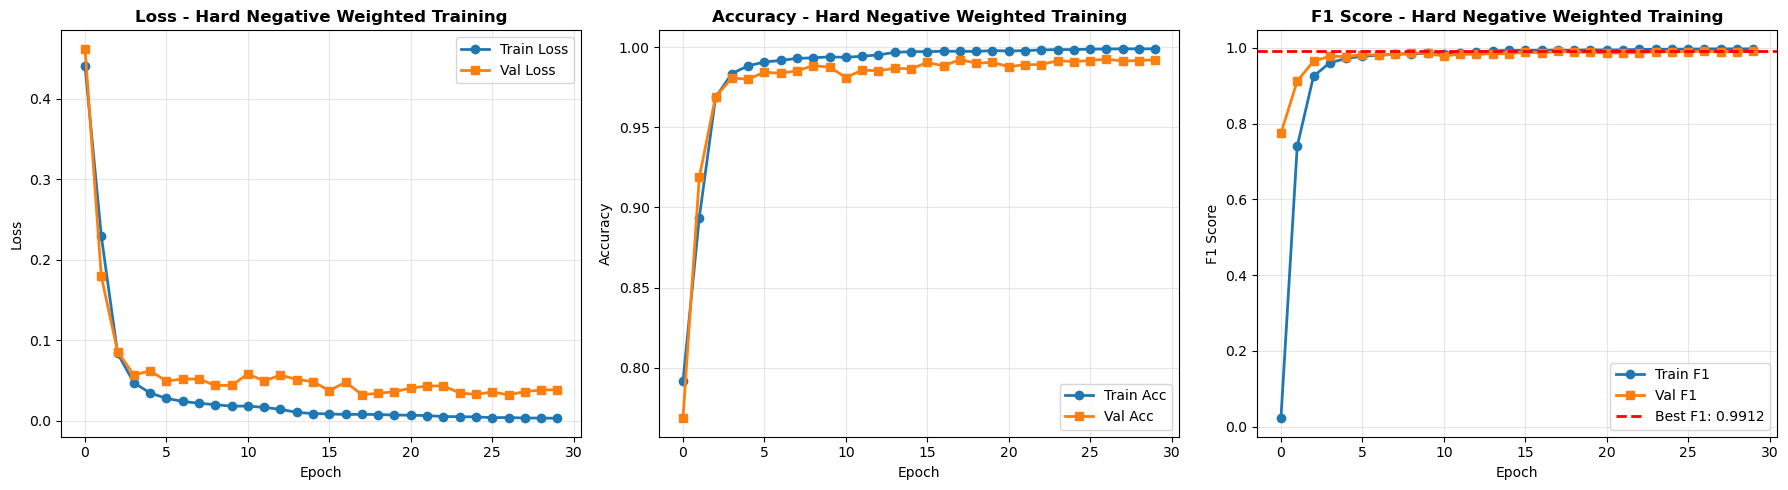

Training history plot saved as 'training_history_siamese_cnn_hard_negatives.png'
Training history CSV saved as 'training_history_siamese_cnn_hard_negatives.csv'

Hard negative model saved to: models\best_siamese_cnn_hard_negatives.pth
Model parameters: 273,601


In [46]:
# Step 3: Plot and save training history and model for hard negative model
plot_and_save_history(history_hn, 'siamese_cnn_hard_negatives', 'Hard Negative Weighted Training')

# Save the trained hard negative model
model_path = os.path.join('models', 'best_siamese_cnn_hard_negatives.pth')
torch.save(model_hn.state_dict(), model_path)
print(f"\nHard negative model saved to: {model_path}")
print(f"Model parameters: {sum(p.numel() for p in model_hn.parameters()):,}")


In [47]:
# Step 4: Load and validate hard negative model
model_hn, cm_hn, precision_hn, recall_hn, specificity_hn, final_f1_hn = load_model_and_validate(
    'siamese_cnn_hard_negatives', val_loader, criterion, device
)



VALIDATING SIAMESE_CNN_HARD_NEGATIVES



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9952    0.9912    0.9932      3963
    Duplicate     0.9882    0.9935    0.9908      2938

     accuracy                         0.9922      6901
    macro avg     0.9917    0.9924    0.9920      6901
 weighted avg     0.9922    0.9922    0.9922      6901


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     3928     35
        Pos       19   2919

Additional Metrics:
  Precision: 0.9882
  Recall (Sensitivity): 0.9935
  Specificity: 0.9912
  F1 Score: 0.9908

Validation Results:
  Loss: 0.0384
  Accuracy: 0.9922
  F1 Score: 0.9908


In [54]:
# Step 5: Test hard negative model on augmented test set
test_loss_hn, test_acc_hn, _, test_labels_hn, test_preds_hn, test_probs_hn = evaluate(model_hn, test_loader, criterion, device)
cm_test_hn, precision_test_hn, recall_test_hn, specificity_test_hn, f1_test_hn = print_evaluation_report(test_labels_hn, test_preds_hn, test_probs_hn)

print(f"\nHard Negatives Model - Augmented Test Results:")
print(f"Test Loss: {test_loss_hn:.4f}")
print(f"Test Precision: {precision_test_hn:.4f}")
print(f"Test Recall: {recall_test_hn:.4f}")
print(f"Test Specificity: {specificity_test_hn:.4f}")
print(f"Test F1: {f1_test_hn:.4f}")



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9916    0.9954      4427
    Duplicate     0.9880    0.9987    0.9933      3048

     accuracy                         0.9945      7475
    macro avg     0.9935    0.9952    0.9943      7475
 weighted avg     0.9946    0.9945    0.9945      7475


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     4390     37
        Pos        4   3044

Additional Metrics:
  Precision: 0.9880
  Recall (Sensitivity): 0.9987
  Specificity: 0.9916
  F1 Score: 0.9933

Hard Negatives Model - Augmented Test Results:
Test Loss: 0.0224
Test Precision: 0.9880
Test Recall: 0.9987
Test Specificity: 0.9916
Test F1: 0.9933


In [57]:
# Step 6: Test hard negative model on non-augmented test set
test_loss_noaug_hn, test_acc_noaug_hn, _, test_labels_noaug_hn, test_preds_noaug_hn, test_probs_noaug_hn = evaluate(model_hn, test_loader_noaug, criterion, device)
cm_test_noaug_hn, precision_test_noaug_hn, recall_test_noaug_hn, specificity_test_noaug_hn, f1_test_noaug_hn = print_evaluation_report(test_labels_noaug_hn, test_preds_noaug_hn, test_probs_noaug_hn)

print(f"\nHard Negatives Model - Non-Augmented Test Results:")
print(f"Test Loss: {test_loss_noaug_hn:.4f}")
print(f"Test Precision: {precision_test_noaug_hn:.4f}")
print(f"Test Recall: {recall_test_noaug_hn:.4f}")
print(f"Test Specificity: {specificity_test_noaug_hn:.4f}")
print(f"Test F1: {f1_test_noaug_hn:.4f}")



DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Non-Duplicate     0.9991    0.9915    0.9953      2346
    Duplicate     0.9870    0.9987    0.9928      1524

     accuracy                         0.9943      3870
    macro avg     0.9931    0.9951    0.9941      3870
 weighted avg     0.9944    0.9943    0.9943      3870


Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg     2326     20
        Pos        2   1522

Additional Metrics:
  Precision: 0.9870
  Recall (Sensitivity): 0.9987
  Specificity: 0.9915
  F1 Score: 0.9928

Hard Negatives Model - Non-Augmented Test Results:
Test Loss: 0.0225
Test Precision: 0.9870
Test Recall: 0.9987
Test Specificity: 0.9915
Test F1: 0.9928


In [59]:
# Step 7: Comparison focused on Hard Negatives results
print("\n" + "="*80)
print("HARD NEGATIVE WEIGHTING - TEST SET EVALUATION")
print("="*80)

print(f"\nValidation Results:")
print(f"  Hard Negative F1: {final_f1_hn:.4f}")

print(f"\nTest Results (Augmented Data):")
print(f"  Test F1: {f1_test_hn:.4f}")
print(f"  Test Precision: {precision_test_hn:.4f}")
print(f"  Test Recall: {recall_test_hn:.4f}")
print(f"  Test Specificity: {specificity_test_hn:.4f}")

print(f"\nTest Results (Non-Augmented Data):")
print(f"  Test F1: {f1_test_noaug_hn:.4f}")
print(f"  Test Precision: {precision_test_noaug_hn:.4f}")
print(f"  Test Recall: {recall_test_noaug_hn:.4f}")
print(f"  Test Specificity: {specificity_test_noaug_hn:.4f}")

print(f"\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print(f"✓ Hard negative weighting successfully applied and validated")
print(f"✓ Model generalization: {final_f1_hn:.4f} (val) → {f1_test_noaug_hn:.4f} (test non-aug)")

# Save summary results
with open('hard_negative_final_results.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("HARD NEGATIVE WEIGHTING - FINAL RESULTS\n")
    f.write("="*80 + "\n")
    f.write(f"\nValidation F1: {final_f1_hn:.4f}\n")
    f.write(f"Test F1 (Augmented): {f1_test_hn:.4f}\n")
    f.write(f"Test F1 (Non-Augmented): {f1_test_noaug_hn:.4f}\n")
    f.write(f"\nTest Metrics (Non-Augmented):\n")
    f.write(f"  Precision: {precision_test_noaug_hn:.4f}\n")
    f.write(f"  Recall: {recall_test_noaug_hn:.4f}\n")
    f.write(f"  Specificity: {specificity_test_noaug_hn:.4f}\n")

print("\n✓ Results saved to: hard_negative_final_results.txt")



HARD NEGATIVE WEIGHTING - TEST SET EVALUATION

Validation Results:
  Hard Negative F1: 0.9908

Test Results (Augmented Data):
  Test F1: 0.9933
  Test Precision: 0.9880
  Test Recall: 0.9987
  Test Specificity: 0.9916

Test Results (Non-Augmented Data):
  Test F1: 0.9928
  Test Precision: 0.9870
  Test Recall: 0.9987
  Test Specificity: 0.9915

KEY INSIGHTS:
✓ Hard negative weighting successfully applied and validated
✓ Model generalization: 0.9908 (val) → 0.9928 (test non-aug)

✓ Results saved to: hard_negative_final_results.txt


## Step 8: Comprehensive Test Evaluation

This section evaluates the hard negative weighted model on multiple test configurations:
1. **Augmented Test Set (Whole)**: Tests on entire augmented test dataset
2. **Augmented Test Set (Hard Positives)**: Tests on duplicates with different last names + all negatives
3. **Non-Augmented Test Set (Whole)**: Tests on entire non-augmented test dataset  
4. **Non-Augmented Test Set (Hard Positives)**: Tests on hard positives subset + all negatives


In [ ]:
### Test 1: Augmented Test Set (Whole Set)

print("\n" + "="*80)
print("TEST 1: AUGMENTED TEST SET - WHOLE SET")
print("="*80)

# Evaluate on whole augmented test set
test_loss_aug_whole, test_acc_aug_whole, _, test_labels_aug_whole, test_preds_aug_whole, test_probs_aug_whole = evaluate(
    model_hn, test_loader, criterion, device
)
cm_aug_whole, prec_aug_whole, rec_aug_whole, spec_aug_whole, f1_aug_whole = print_evaluation_report(
    test_labels_aug_whole, test_preds_aug_whole, test_probs_aug_whole
)

print(f"\nAugmented Test Set (Whole) Results:")
print(f"  Samples: {len(test_aug_data)}")
print(f"  Loss: {test_loss_aug_whole:.4f}")
print(f"  Precision: {prec_aug_whole:.4f}")
print(f"  Recall: {rec_aug_whole:.4f}")
print(f"  Specificity: {spec_aug_whole:.4f}")
print(f"  F1 Score: {f1_aug_whole:.4f}")


In [ ]:
### Test 2: Augmented Test Set (Hard Positives - Different Last Names + All Negatives)

print("\n" + "="*80)
print("TEST 2: AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)")
print("="*80)

# Filter for hard positives (duplicates with different last names) + all negatives
filtered_aug_test = test_aug_data[
    ((test_aug_data['label'] == 1) & (test_aug_data['last_name_1'] != test_aug_data['last_name_2'])) | 
    (test_aug_data['label'] == 0)
]

# Create filtered dataloader
filtered_test_dataset_aug = PairTextDataset(
    data=filtered_aug_test, 
    char_to_idx=char_to_idx, 
    max_len=MAX_LEN, 
    features=FEATURES
)
filtered_test_loader_aug = DataLoader(
    filtered_test_dataset_aug, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0
)

# Evaluate on filtered augmented test set
test_loss_aug_hp, test_acc_aug_hp, _, test_labels_aug_hp, test_preds_aug_hp, test_probs_aug_hp = evaluate(
    model_hn, filtered_test_loader_aug, criterion, device
)
cm_aug_hp, prec_aug_hp, rec_aug_hp, spec_aug_hp, f1_aug_hp = print_evaluation_report(
    test_labels_aug_hp, test_preds_aug_hp, test_probs_aug_hp
)

print(f"\nAugmented Test Set (Hard Positives) Results:")
print(f"  Samples: {len(filtered_aug_test)} (filtered from {len(test_aug_data)})")
print(f"  Duplicates (DLN): {(filtered_aug_test['label'] == 1).sum()}")
print(f"  Non-Duplicates: {(filtered_aug_test['label'] == 0).sum()}")
print(f"  Loss: {test_loss_aug_hp:.4f}")
print(f"  Precision: {prec_aug_hp:.4f}")
print(f"  Recall: {rec_aug_hp:.4f}")
print(f"  Specificity: {spec_aug_hp:.4f}")
print(f"  F1 Score: {f1_aug_hp:.4f}")


In [ ]:
### Test 3: Non-Augmented Test Set (Whole Set)

print("\n" + "="*80)
print("TEST 3: NON-AUGMENTED TEST SET - WHOLE SET")
print("="*80)

# Evaluate on whole non-augmented test set
test_loss_noaug_whole, test_acc_noaug_whole, _, test_labels_noaug_whole, test_preds_noaug_whole, test_probs_noaug_whole = evaluate(
    model_hn, test_loader_noaug, criterion, device
)
cm_noaug_whole, prec_noaug_whole, rec_noaug_whole, spec_noaug_whole, f1_noaug_whole = print_evaluation_report(
    test_labels_noaug_whole, test_preds_noaug_whole, test_probs_noaug_whole
)

print(f"\nNon-Augmented Test Set (Whole) Results:")
print(f"  Samples: {len(test_noaug_data)}")
print(f"  Loss: {test_loss_noaug_whole:.4f}")
print(f"  Precision: {prec_noaug_whole:.4f}")
print(f"  Recall: {rec_noaug_whole:.4f}")
print(f"  Specificity: {spec_noaug_whole:.4f}")
print(f"  F1 Score: {f1_noaug_whole:.4f}")


In [ ]:
### Test 4: Non-Augmented Test Set (Hard Positives - Different Last Names + All Negatives)

print("\n" + "="*80)
print("TEST 4: NON-AUGMENTED TEST SET - HARD POSITIVES (DLN + NEGATIVES)")
print("="*80)

# Filter for hard positives (duplicates with different last names) + all negatives
filtered_noaug_test = test_noaug_data[
    ((test_noaug_data['label'] == 1) & (test_noaug_data['last_name_1'] != test_noaug_data['last_name_2'])) | 
    (test_noaug_data['label'] == 0)
]

# Create filtered dataloader
filtered_test_dataset_noaug = PairTextDataset(
    data=filtered_noaug_test, 
    char_to_idx=char_to_idx, 
    max_len=MAX_LEN, 
    features=FEATURES
)
filtered_test_loader_noaug = DataLoader(
    filtered_test_dataset_noaug, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0
)

# Evaluate on filtered non-augmented test set
test_loss_noaug_hp, test_acc_noaug_hp, _, test_labels_noaug_hp, test_preds_noaug_hp, test_probs_noaug_hp = evaluate(
    model_hn, filtered_test_loader_noaug, criterion, device
)
cm_noaug_hp, prec_noaug_hp, rec_noaug_hp, spec_noaug_hp, f1_noaug_hp = print_evaluation_report(
    test_labels_noaug_hp, test_preds_noaug_hp, test_probs_noaug_hp
)

print(f"\nNon-Augmented Test Set (Hard Positives) Results:")
print(f"  Samples: {len(filtered_noaug_test)} (filtered from {len(test_noaug_data)})")
print(f"  Duplicates (DLN): {(filtered_noaug_test['label'] == 1).sum()}")
print(f"  Non-Duplicates: {(filtered_noaug_test['label'] == 0).sum()}")
print(f"  Loss: {test_loss_noaug_hp:.4f}")
print(f"  Precision: {prec_noaug_hp:.4f}")
print(f"  Recall: {rec_noaug_hp:.4f}")
print(f"  Specificity: {spec_noaug_hp:.4f}")
print(f"  F1 Score: {f1_noaug_hp:.4f}")


In [ ]:
### Summary: Comparison Across All Test Configurations

print("\n" + "="*100)
print("SUMMARY: HARD NEGATIVE WEIGHTING MODEL - ALL TEST CONFIGURATIONS")
print("="*100)

# Create comparison DataFrame
comparison_data = {
    'Test Configuration': [
        'Augmented (Whole)',
        'Augmented (Hard Positives)',
        'Non-Augmented (Whole)',
        'Non-Augmented (Hard Positives)'
    ],
    'Samples': [
        len(test_aug_data),
        len(filtered_aug_test),
        len(test_noaug_data),
        len(filtered_noaug_test)
    ],
    'F1 Score': [f1_aug_whole, f1_aug_hp, f1_noaug_whole, f1_noaug_hp],
    'Precision': [prec_aug_whole, prec_aug_hp, prec_noaug_whole, prec_noaug_hp],
    'Recall': [rec_aug_whole, rec_aug_hp, rec_noaug_whole, rec_noaug_hp],
    'Specificity': [spec_aug_whole, spec_aug_hp, spec_noaug_whole, spec_noaug_hp],
    'Loss': [test_loss_aug_whole, test_loss_aug_hp, test_loss_noaug_whole, test_loss_noaug_hp]
}

summary_df = pd.DataFrame(comparison_data)
print("\n")
print(summary_df.to_string(index=False))
print("\n" + "="*100)

# Save summary to file
summary_df.to_csv('hard_negative_test_summary.csv', index=False)
print("✓ Summary saved to: hard_negative_test_summary.csv")

# Key findings
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print(f"✓ Best F1 (Augmented Whole): {f1_aug_whole:.4f}")
print(f"✓ Best F1 (Augmented Hard Positives): {f1_aug_hp:.4f}")
print(f"✓ Best F1 (Non-Augmented Whole): {f1_noaug_whole:.4f}")
print(f"✓ Best F1 (Non-Augmented Hard Positives): {f1_noaug_hp:.4f}")
print(f"\n✓ Generalization (Augmented → Non-Augmented, Whole): {f1_aug_whole - f1_noaug_whole:.4f} F1 drop")
print(f"✓ Generalization (Augmented → Non-Augmented, Hard Positives): {f1_aug_hp - f1_noaug_hp:.4f} F1 drop")
